In [1]:
# Montar Google Drive (si ejecutamos en Google Colab) y definir directorio de datos
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    data_dir = '/content/drive/MyDrive/NLP/Practica/'
except ImportError:
    data_dir = './'

# Nos aseguramos de que el directorio exista
os.makedirs(data_dir, exist_ok=True)

# Cargamos los datos y resultados anteriores
import pickle
import numpy as np
import time
from sklearn.model_selection import train_test_split

with open(os.path.join(data_dir, 'preprocessed_data.pkl'), 'rb') as f:
    x_train, x_test, y_train, y_test, tfidf, x_train_, x_test_, median_words_rw = pickle.load(f)

with open(os.path.join(data_dir, 'ml_dl_results.pkl'), 'rb') as f:
    y_pred_xgb, xgb_accuracy, xgb_train_time, y_pred_ff, ff_accuracy, ff_train_time = pickle.load(f)

# Definimos funciones auxiliares necesarias
def bold(text):
    return f"\033[1m{text}\033[0m"

def metricas_xgb():
  length_xgb = len(y_pred_xgb)
  count_0_xgb = 0
  count_1_xgb = 0
  for j in range(len(y_pred_xgb)):
    if y_pred_xgb[j] == 0:
      count_0_xgb += 1
    else:
      count_1_xgb += 1
  return count_0_xgb, count_1_xgb, length_xgb

def mostrar_metricas_xgb():
  count_0_xgb, count_1_xgb, length_xgb = metricas_xgb()
  print(bold('Prediction xgb'))
  print(' xgb accuracy: {:>4.2f}'.format(xgb_accuracy*100))
  print(' 0 xgb : {:>4}'.format(count_0_xgb), '({:>6.2f}%)'.format(count_0_xgb/length_xgb * 100))
  print(' 1 xgb : {:>4}'.format(count_1_xgb), '({:>6.2f}%)'.format(count_1_xgb/length_xgb * 100))
  print('\n')

def metricas_ff():
  length_ff = len(y_pred_ff)
  count_0_ff = 0
  count_1_ff = 0
  for j in range(length_ff):
    if y_pred_ff[j] == 0:
      count_0_ff += 1
    else:
      count_1_ff += 1
  return count_0_ff, count_1_ff, length_ff

def mostrar_metricas_ff():
  count_0_ff, count_1_ff, length_ff = metricas_ff()
  print(bold('Prediction ffi'))
  print('  ff accuracy: {:>4.2f}'.format(ff_accuracy*100))
  print('  0 ff : {:>4}'.format(count_0_ff), '({:>6.2f}%)'.format(count_0_ff/length_ff * 100))
  print('  1 ff : {:>4}'.format(count_1_ff), '({:>6.2f}%)'.format(count_1_ff/length_ff * 100))
  print('\n')


Mounted at /content/drive


# 5 - Modelo GRU

## Dependencias

In [2]:
import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.8 MB/s eta 0:00:00


In [3]:
cores = multiprocessing.cpu_count() # Contamos el número de cores en el ordenador
print ('Available cores:', cores)

Available cores: 2


## Embedding

En esta parte creamos el embedding que nos da la relación semántica entre las palabras del corpus.

In [4]:
# We're creating embeddings for GRU model
w2v_model = Word2Vec(min_count=20,
                     window=2,
                     vector_size=300,
                     sample=6e-5,
                     alpha=0.03,
                     min_alpha=0.0007,
                     negative=20,
                     workers=cores-1)

In [5]:
t_start = time.time()
sent = [row.split() for row in x_train]
w2v_model.build_vocab(sent, progress_per=10000)
t_end = time.time()

In [6]:
print('Time to build the vocabulary: {} mins'.format(round((t_end - t_start) / 60, 2)))
print('The vocabulary is composed by {} words'.format(len(w2v_model.wv.key_to_index)))

Time to build the vocabulary: 0.0 mins
The vocabulary is composed by 1277 words


In [7]:
# Training word2vec model
t_start = time.time()

w2v_model.train(sent, total_examples=w2v_model.corpus_count, epochs=30, report_delay=1)

t_end = time.time()


In [8]:
# Nos quedamos con las 100 palabras más utilizadas
top_words = list(w2v_model.wv.key_to_index.keys())[:100]

# Extraemos los vectores
vectors = np.array([w2v_model.wv[word] for word in top_words])

In [9]:
from sklearn.decomposition import PCA

# PCA - Reducimos dimensiones
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)

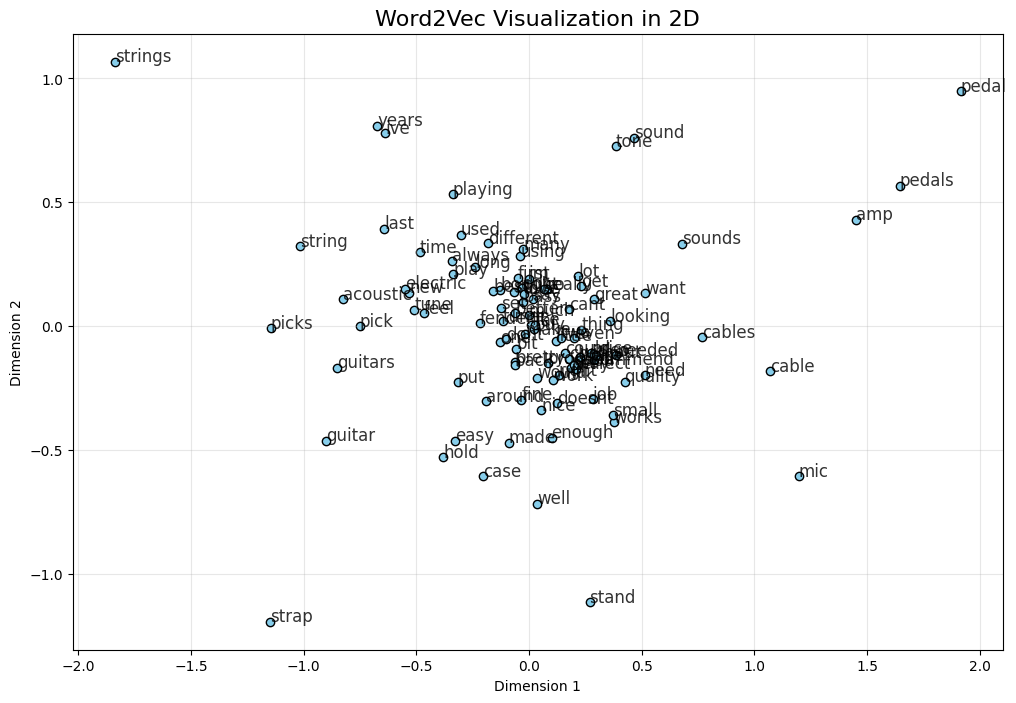

In [10]:
# Dibujamos el gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Scatter plot
x = reduced_vectors[:, 0]
y = reduced_vectors[:, 1]

plt.scatter(x, y, color='skyblue', edgecolors='black')

# Add labels to each point
for i, word in enumerate(top_words):
    plt.annotate(word, (x[i], y[i]), fontsize=12, alpha=0.8)

plt.title('Word2Vec Visualization in 2D', fontsize=16)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:

print('Time to train the model: {} mins'.format(round((t_end - t_start) / 60, 2)))

Time to train the model: 0.09 mins


### Información del word2vec generado

In [12]:
w2v_model.wv.most_similar(positive=["guitar"])

[('guitars', 0.987044632434845),
 ('neck', 0.9796016216278076),
 ('locks', 0.975145161151886),
 ('straps', 0.9686566591262817),
 ('lock', 0.9598761200904846),
 ('uke', 0.9590210318565369),
 ('nylon', 0.9588447213172913),
 ('locking', 0.9586886167526245),
 ('hold', 0.956464409828186),
 ('acoustic', 0.956436038017273)]

In [13]:
w2v_model.wv.most_similar(positive=["string"])


[('acoustic', 0.9754698276519775),
 ('elixir', 0.9698543548583984),
 ('wound', 0.9670790433883667),
 ('bronze', 0.9635582566261292),
 ('coated', 0.9631199836730957),
 ('martin', 0.962031364440918),
 ('daddario', 0.9616798162460327),
 ('steel', 0.9593961834907532),
 ('last', 0.9581807255744934),
 ('longer', 0.958154559135437)]

In [14]:
w2v_model.wv.most_similar(positive=["drum"])

[('portable', 0.9954089522361755),
 ('drums', 0.9950161576271057),
 ('equipment', 0.993976891040802),
 ('stage', 0.9937447905540466),
 ('function', 0.9934114813804626),
 ('need', 0.9933651685714722),
 ('able', 0.9931591153144836),
 ('desktop', 0.9928667545318604),
 ('mike', 0.9924976229667664),
 ('device', 0.9920425415039062)]

In [15]:
w2v_model.wv.similarity('guitar', 'string')

np.float32(0.90897965)

In [16]:
w2v_model.wv.similarity('microphone', 'banjo')

np.float32(0.7942375)

In [17]:
w2v_model.wv.doesnt_match(['strings', 'guitar', 'device'])

'strings'

In [18]:
w2v_model.wv.vectors

array([[-0.09268105,  0.09548959,  0.01112183, ..., -0.11176256,
         0.02646852,  0.17833765],
       [-0.18476938,  0.07363865, -0.06206161, ..., -0.09474501,
         0.04715651,  0.13696492],
       [-0.09311258,  0.08871922, -0.04850857, ..., -0.06629765,
         0.05099511,  0.0928389 ],
       ...,
       [-0.17680179,  0.07628514, -0.06107659, ..., -0.07584647,
         0.05030879,  0.10233977],
       [-0.17191096,  0.08786197, -0.05125877, ..., -0.08637946,
         0.04450213,  0.1323358 ],
       [-0.1527446 ,  0.07076406, -0.05378653, ..., -0.08316445,
         0.02411805,  0.13048066]], dtype=float32)

## Tokenizing & Padding train data

La tokenización se encarga de pasar cada palabra a número para que pueda ser tratada por el modelo.

El padding se ocupa de dejar todos los registros de la misma longitud para que el modelo lo trate de forma eficiente.

In [19]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = int(median_words_rw)  # sequence length


# Initialize tokenizer
tokenizr = Tokenizer(oov_token="<OOV>")
tokenizr.fit_on_texts(x_train)

vocab_size =  len(tokenizr.word_index) + 1  # vocabulary size

# texte to sequence
seq = tokenizr.texts_to_sequences(x_train)
x_train_gru = pad_sequences(seq, padding='post', truncating='post', maxlen=max_words)

seq_test = tokenizr.texts_to_sequences(x_test)
x_test_gru = pad_sequences(seq_test, padding='post', truncating='post', maxlen=max_words)


In [20]:
print(bold('Raw             :'), x_train[100:])
print(bold('Vocabulary size :'), vocab_size)
print(bold('Sequences       :'), list(seq)[:2])
print(bold('Pad sequences   :'), list(x_train_gru)[:2])
print(bold('Word index      :'), list(tokenizr.word_index)[:50])


Raw             : ['elixir strings nice slick last forever compared standard stringsbut admit addario strings good replaced often money want try technology advanced strings dont think disappointed people say slick'
 'harmonica barely fits holder adjustment distance mouth harmonica cant get harmonica adjusted close enough play unless modify'
 'unfortunately wasnt aware slides come sizes got medium need large medium fits pinky finger thats okay prefered fit index finger id controli cannot fault slide foolish choice'
 ...
 'simple humidifier guitars round sound hole would work fhole archtop types instruments mandolin ukulele inside sturdy plastic case appears ordinary kitchen sponge use distilled water recommended last'
 'les paul heavy strap would constantly fall decided get set strap locks installed minutes really dont change look guitar need nut driver screw lock strap dont locks'
 'guitar stand built good buy cost would purchase']
Vocabulary size : 15198
Sequences       : [[5, 23, 118

In [21]:
# Obtenemos la dimensión del Word2Vec
embedding_dim = w2v_model.vector_size  # 300

# creamos matriz vacía
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Llenamos la matriz
for word, i in tokenizr.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

## Entrenar el modelo

In [22]:
from keras.models import Sequential
from keras.layers import Embedding,  Dense, Dropout, GRU

embedding_size = 32
gru_model = Sequential()
gru_model.add(Embedding(vocab_size, embedding_dim, weights=[embedding_matrix]))
gru_model.add(GRU(64))
gru_model.add(Dense(1, activation='sigmoid'))

print(gru_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     4,559,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,559,400 (17.39 MB)

 Trainable params: 4,559,400 (17.39 MB)

 Non-trainable params: 0 (0.00 B)

None


In [23]:
gru_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [24]:
# Split de las secuencias rellenadas
X_train_final, X_valid, y_train_final, y_valid = train_test_split(
    x_train_gru, y_train, test_size=0.2, random_state=42
)

In [25]:
batch_size = 64
num_epochs = 1

gru_model.fit(X_train_final, y_train_final,
              validation_data=(X_valid, y_valid),
              batch_size=batch_size,
              epochs=num_epochs)

97/97 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.8751 - loss: 0.3824 - val_accuracy: 0.8700 - val_loss: 0.3849


In [26]:
import os

In [27]:
# guardamos el modelo en el colab
cache_dir='./'
model_file = "gru_model.h5"  # HDF5 file
gru_model.save( model_file)

In [28]:
# Obtenemos accuracy
scores = gru_model.evaluate(X_valid, y_valid, verbose=0)  # returns loss and other metrics specified in model.compile()
gru_accuracy = scores[1]*100
print("Test accuracy: {:>6.2f}%".format(gru_accuracy, 2))  # scores[1] should correspond to accuracy if you passed in metrics=['accuracy']

Test accuracy:  87.00%


## Métricas y conclusiones (GRU)

In [29]:
y_pred_gru_raw = gru_model.predict(X_valid)
gru_pred = y_pred_gru_raw
y_pred_gru = (y_pred_gru_raw > 0.5).astype(int).flatten()

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [30]:
def metricas_gru():
  # Initializing array of integers
  y_pred_gru = np.empty_like(gru_pred)

  for i in range(len(y_pred_gru)):
    if y_pred_gru[i][0] == np.nan:
      y_pred_gru[i][0] = 0
    try:
      y_pred_gru[i] = int(np.round(y_pred_gru[i][0]))
    except:
      y_pred_gru[i] = 0


  # Printing predictions

  length_gru = len(y_pred_gru)
  count_0_gru = 0
  count_1_gru = 0
  for j in range(len(y_pred_gru)):
    if y_pred_gru[j] == 0:
      count_0_gru += 1
    else:
      count_1_gru += 1
  return count_0_gru, count_1_gru, length_gru

def mostrar_metricas_gru():
  count_0_gru, count_1_gru, length_gru   = metricas_gru()
  print(bold('Prediction gru'))
  print('  gru accuracy: {:>4.2f}'.format(gru_accuracy))
  print('  0 gru : {:>4}'.format(count_0_gru), '({:>6.2f}%)'.format(count_0_gru/length_gru * 100))
  print('  1 gru : {:>4}'.format(count_1_gru), '({:>6.2f}%)'.format(count_1_gru/length_gru * 100))
  print('\n')

In [31]:
mostrar_metricas_gru()
mostrar_metricas_ff()
mostrar_metricas_xgb()

Prediction gru
  gru accuracy: 87.00
  0 gru : 1458 ( 94.74%)
  1 gru :   81 (  5.26%)


Prediction ffi
  ff accuracy: 83.28
  0 ff :  309 ( 12.04%)
  1 ff : 2257 ( 87.96%)


Prediction xgb
 xgb accuracy: 78.92
 0 xgb :  569 ( 22.17%)
 1 xgb : 1997 ( 77.83%)




In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
# metricas2 feat. Deepseek + Gemini
def metricas2(y_true, y_pred, nombre):
    """Calcula las 4 métricas principales"""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{nombre}")

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # Matriz de confusión simple
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nMatriz de Confusión:")
    print(f"              Predicho 0  Predicho 1")
    print(f"Real 0        {cm[0,0]:6d}       {cm[0,1]:6d}")
    print(f"Real 1        {cm[1,0]:6d}       {cm[1,1]:6d}")

    return {'modelo': nombre, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1}

# Calcular para cada modelo
resultados = []
resultados.append(metricas2(y_test, y_pred_xgb, "XGBoost"))
resultados.append(metricas2(y_test, y_pred_ff, "Feed-Forward"))

print(f"\nDebugging GRU prediction length:")
print(f"  Shape of y_test: {y_test.shape}")
print(f"  Shape of x_test_gru: {x_test_gru.shape}")
y_pred_gru_raw_test = gru_model.predict(x_test_gru)
print(f"  Shape of gru_model.predict(x_test_gru): {y_pred_gru_raw_test.shape}")
y_pred_gru_test = (y_pred_gru_raw_test > 0.5).astype(int).flatten()
print(f"  Shape of y_pred_gru_test (flattened): {y_pred_gru_test.shape}")

resultados.append(metricas2(y_test, y_pred_gru_test, "GRU"))

# Comparación de modelos

print("\nComparación de Modelos")

df = pd.DataFrame(resultados)
df = df.set_index('modelo')
print("\n", df.round(4))

# Encontrar el mejor modelo
mejor = df['f1'].idxmax()
print(f"\nMejor modelo por F1-Score: {mejor}")
print(f"   F1-Score: {df.loc[mejor, 'f1']:.4f}")


XGBoost
Accuracy:  0.7892
Precision: 0.8530
Recall:    0.7892
F1-Score:  0.8138

Matriz de Confusión:
              Predicho 0  Predicho 1
Real 0           169          141
Real 1           400         1856

Feed-Forward
Accuracy:  0.8328
Precision: 0.8326
Recall:    0.8328
F1-Score:  0.8327

Matriz de Confusión:
              Predicho 0  Predicho 1
Real 0            95          215
Real 1           214         2042

Debugging GRU prediction length:
  Shape of y_test: (2566,)
  Shape of x_test_gru: (2566, 17)
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
  Shape of gru_model.predict(x_test_gru): (2566, 1)
  Shape of y_pred_gru_test (flattened): (2566,)

GRU
Accuracy:  0.8792
Precision: 0.7730
Recall:    0.8792
F1-Score:  0.8227

Matriz de Confusión:
              Predicho 0  Predicho 1
Real 0             0          310
Real 1             0         2256

Comparación de Modelos

               accuracy  precision  recall      f1
modelo                                           
XGBoost        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


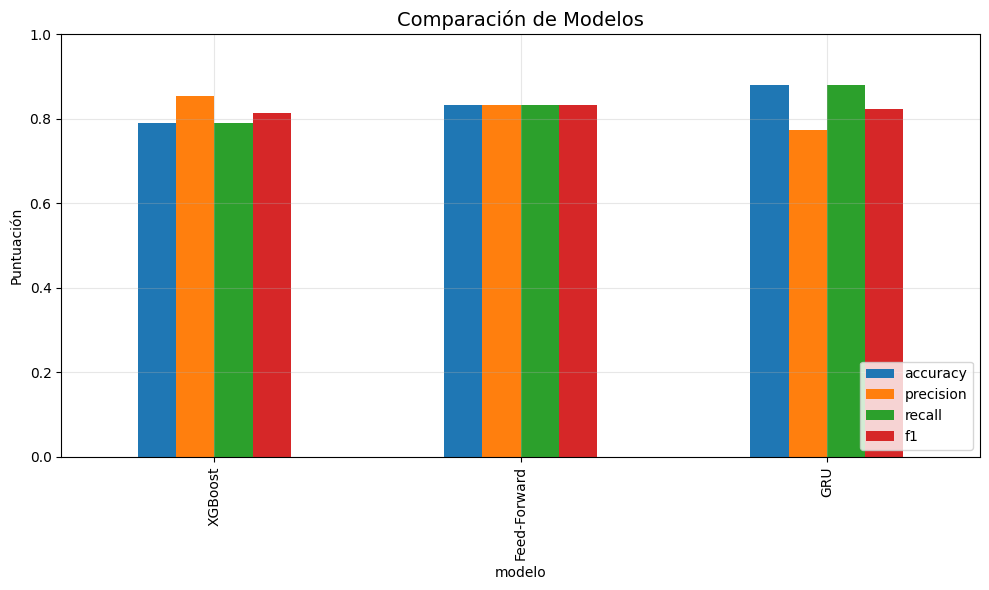

In [34]:
# Gráfico de comparación


df[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', figsize=(10,6))

plt.title('Comparación de Modelos', fontsize=14)
plt.ylabel('Puntuación')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()